In [1]:
import math
import torch
import torch.nn as nn
import torch.optim as optim
import numpy as np
import matplotlib.pyplot as plt
from model import *
import pandas as pd
from utils import *
import pickle as pkl
import os
from matplotlib.colors import LogNorm
import seaborn as sns
sns.set(style='whitegrid')
device = torch.device("cuda")

In [2]:
def sample_batch_singindex(B, d_in, device="cuda"):
    x = torch.randn(B, d_in, device=device) / math.sqrt(d_in)
    y = f_hermite(x @ teacher_weights).reshape(-1, 1)
    return x, y


def train_ntp_wntk(d_in, x_data, widths, B, T, lrs, sample_batch_fn, type="NTP", device="cuda"):
    train_losses = {w: {lr:[] for lr in lrs} for w in widths}
    ntk_diffs = {w: {lr:[] for lr in lrs} for w in widths}
    loss_fn = nn.MSELoss()
    for width in widths:
        for lr in lrs:
            has_nan = False
            model = MLP2NTP(d_in, width, 1, type).to(device)
            model.init_weights()
            optimizer = model.init_optimizer(lr)
            model.train()
            base_ntk = model.ntk_kernel(x_data)
            ntk_diffs[width][lr].append(base_ntk.cpu().numpy())
            for step in range(T):
                if has_nan:
                    train_losses[width][lr].append(np.nan)
                    continue
                x, y_true = sample_batch_fn(B, d_in, device=device)
                optimizer.zero_grad()
                y_pred = model(x)
                loss = loss_fn(y_pred, y_true)
                loss.backward()
                optimizer.step()
                train_losses[width][lr].append(loss.item())
                if torch.isnan(loss):
                    has_nan = True
                if step > 0 and (step < 1000 or step % 15 == 0):
                    ntk_diff = model.ntk_kernel(x_data) - base_ntk
                    ntk_diffs[width][lr].append(ntk_diff.cpu().numpy())
                if step % 2000 == 0 and step > 100:
                    print(f"Step {step} for width {width}, lr {lr}, Loss: {np.mean(train_losses[width][lr][-1000:])}")
            if has_nan:
                print(f"Model {width} with lr {lr} has NaN loss")
    return train_losses, ntk_diffs

In [3]:
d_in = 16
def f_hermite(x): return (x**3 - 3*x)/math.sqrt(6)
torch.manual_seed(32)
teacher_weights = torch.randn(d_in, 1, device=device)
teacher_weights /= teacher_weights.norm()
teacher_weights *= math.sqrt(d_in)
x_data = torch.randn(100, d_in, device=device) / math.sqrt(d_in)

In [4]:
widths = [512, 1024, 2048, 4096]
lrs = [0.3]
T = 40001
B = 2048
type = "NTP"
train_losses_ntp, ntk_diffs_ntp = train_ntp_wntk(d_in, x_data, widths, B, T, lrs, sample_batch_singindex, type, device)

Step 2000 for width 512, lr 0.3, Loss: 0.7390668116807938
Step 4000 for width 512, lr 0.3, Loss: 0.3586527056545019
Step 6000 for width 512, lr 0.3, Loss: 0.2745251491069794
Step 8000 for width 512, lr 0.3, Loss: 0.22789981099963189
Step 10000 for width 512, lr 0.3, Loss: 0.18699397728592157
Step 12000 for width 512, lr 0.3, Loss: 0.15602290243655442
Step 14000 for width 512, lr 0.3, Loss: 0.12952158983051776
Step 16000 for width 512, lr 0.3, Loss: 0.1164192059636116
Step 18000 for width 512, lr 0.3, Loss: 0.09851439000666141
Step 20000 for width 512, lr 0.3, Loss: 0.08866013142839074
Step 22000 for width 512, lr 0.3, Loss: 0.08144644135609269
Step 24000 for width 512, lr 0.3, Loss: 0.07346596006676555
Step 26000 for width 512, lr 0.3, Loss: 0.06442065012082457
Step 28000 for width 512, lr 0.3, Loss: 0.05833257382921875
Step 30000 for width 512, lr 0.3, Loss: 0.055897651646286246
Step 32000 for width 512, lr 0.3, Loss: 0.052171900052577255
Step 34000 for width 512, lr 0.3, Loss: 0.0478

In [5]:
widths = [512, 1024, 2048, 4096]
lrs = [0.02]
T = 40001
type = "MUP"
train_losses_mup, ntk_diffs_mup = train_ntp_wntk(d_in, x_data, widths, B, T, lrs, sample_batch_singindex, type, device)

Step 2000 for width 512, lr 0.02, Loss: 0.8898208639025689
Step 4000 for width 512, lr 0.02, Loss: 0.3386770646572113
Step 6000 for width 512, lr 0.02, Loss: 0.2092095450758934
Step 8000 for width 512, lr 0.02, Loss: 0.14865098303928972
Step 10000 for width 512, lr 0.02, Loss: 0.10664582731202245
Step 12000 for width 512, lr 0.02, Loss: 0.08140462063625455
Step 14000 for width 512, lr 0.02, Loss: 0.06411710658296943
Step 16000 for width 512, lr 0.02, Loss: 0.05244301988463849
Step 18000 for width 512, lr 0.02, Loss: 0.044759563961066305
Step 20000 for width 512, lr 0.02, Loss: 0.03814046756457538
Step 22000 for width 512, lr 0.02, Loss: 0.034476324759423735
Step 24000 for width 512, lr 0.02, Loss: 0.030091965372674168
Step 26000 for width 512, lr 0.02, Loss: 0.02869837639061734
Step 28000 for width 512, lr 0.02, Loss: 0.02570307719055563
Step 30000 for width 512, lr 0.02, Loss: 0.022142968732863665
Step 32000 for width 512, lr 0.02, Loss: 0.02001797912362963
Step 34000 for width 512, l

In [6]:
steps_range= []
for step in range(T):
    if step > 0 and (step < 1000 or step % 15 == 0):
        steps_range.append(step)
print(len(steps_range))

3599


In [7]:
norms_ntk_diffs_mup = []
for width in widths:
    norms_ntk_diffs_mup.append(np.linalg.norm(np.array(ntk_diffs_mup[width][0.02]), ord=2, axis=(-2, -1)))
    print(norms_ntk_diffs_mup[-1].shape)
norms_ntk_diffs_ntp = []
for width in widths:
    norms_ntk_diffs_ntp.append(np.linalg.norm(np.array(ntk_diffs_ntp[width][0.3]), ord=2, axis=(-2, -1)))
    print(norms_ntk_diffs_ntp[-1].shape)

(3600,)
(3600,)
(3600,)
(3600,)
(3600,)
(3600,)
(3600,)
(3600,)


Text(0.5, 1.0, '||NTK(T) - NTK(0)||_{op} / ||NTK(0)||_{op}')

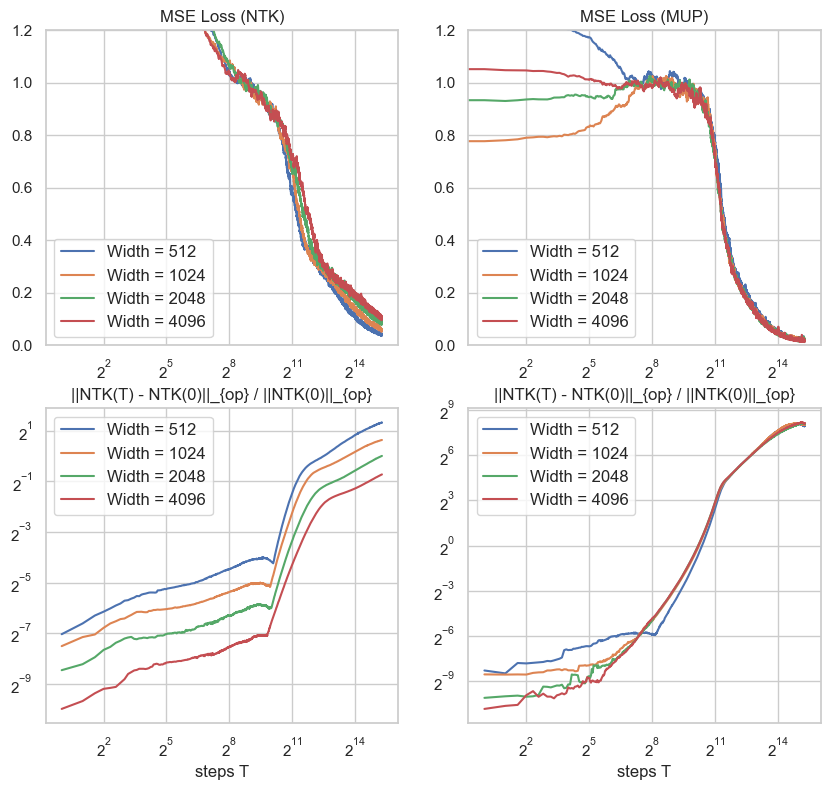

In [8]:
widths = [512, 1024, 2048, 4096]
axes, fig = plt.subplots(2,2, figsize=(10, 9))

ax = fig[0, 0]
for i, width in enumerate(widths):
    losses = train_losses_ntp[width][0.3]
    lossesema = pd.Series(losses).ewm(halflife=50, adjust=False).mean().to_numpy()
    ax.plot(lossesema, label=f"Width = {width}")
ax.legend(fontsize=12)
ax.set_ylim(0, 1.2)
ax.set_xscale("log", base=2)

ax.set_title("MSE Loss (NTK)")
ax = fig[1, 0]
for i, width in enumerate(widths):
    ax.plot(steps_range,  norms_ntk_diffs_ntp[i][1:] / norms_ntk_diffs_ntp[i][0], label=f"Width = {width}")
ax.legend(fontsize=12)
ax.set_xlabel("steps T")
ax.set_yscale("log", base=2)
ax.set_xscale("log", base=2)
ax.set_title("||NTK(T) - NTK(0)||_{op} / ||NTK(0)||_{op}")

ax = fig[0, 1]
for i, width in enumerate(widths):
    losses = train_losses_mup[width][0.02]
    lossesema = pd.Series(losses).ewm(halflife=50, adjust=False).mean().to_numpy()
    ax.plot(lossesema, label=f"Width = {width}")
ax.legend(fontsize=12)
ax.set_ylim(0, 1.2)
ax.set_xscale("log", base=2)
ax.set_title("MSE Loss (MUP)")

ax = fig[1, 1]
for i, width in enumerate(widths):
    ax.plot(steps_range, norms_ntk_diffs_mup[i][1:] / norms_ntk_diffs_mup[i][0], label=f"Width = {width}")
ax.legend(fontsize=12)
ax.set_xlabel("steps T")
ax.set_yscale("log", base=2)
ax.set_xscale("log", base=2)
ax.set_title("||NTK(T) - NTK(0)||_{op} / ||NTK(0)||_{op}")

C:\Users\Petyrrr\AppData\Local\Temp\ipykernel_8708\1425133560.py:4: RuntimeWarning: divide by zero encountered in divide
  plt.plot(steps_range, curves[i] / curves[1])


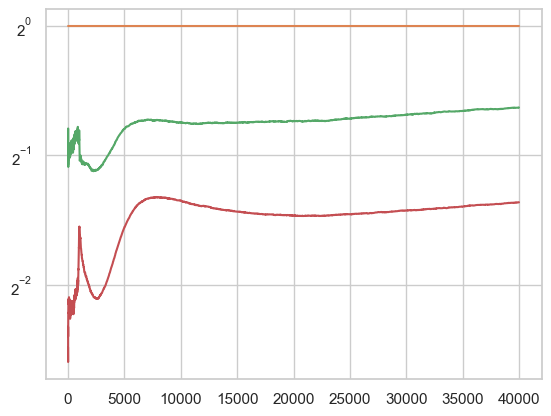

In [9]:
curves = np.zeros((len(widths), len(steps_range)))
for i, width in enumerate(widths):
    curves[i] = norms_ntk_diffs_ntp[i][1:] / norms_ntk_diffs_ntp[i][0]
    plt.plot(steps_range, curves[i] / curves[1])
plt.yscale("log", base=2)

In [12]:
torch.cuda.empty_cache()
print(torch.cuda.memory_allocated() / 1e9, "GB allocated")
print(torch.cuda.memory_reserved() / 1e9, "GB reserved")

0.017046528 GB allocated
0.023068672 GB reserved


In [11]:
#train_losses_ntp, ntk_diffs_ntp
pkl.dump(train_losses_ntp, open("assets_sim_kernels/train_losses_ntp.pkl", "wb"))
pkl.dump(ntk_diffs_ntp, open("assets_sim_kernels/ntk_diffs_ntp.pkl", "wb"))
pkl.dump(train_losses_mup, open("assets_sim_kernels/train_losses_mup.pkl", "wb"))
pkl.dump(ntk_diffs_mup, open("assets_sim_kernels/ntk_diffs_mup.pkl", "wb"))